# 9 — Reward Shaping

Specifying what you actually want · SOC4180 Robot and AI

Hong Jeong

<figure>
<a
href="https://colab.research.google.com/github/gnoejh/soc4180/blob/main/weeks/09-reward/lab.ipynb"><img
src="https://colab.research.google.com/assets/colab-badge.svg" /></a>
<figcaption>Open In Colab</figcaption>
</figure>

**Before you start, two things:**

1.  **Runtime → Change runtime type → T4 GPU.** Not for training —
    MuJoCo renders video through EGL on Colab, and that needs the GPU
    runtime.
2.  **File → Save a copy in Drive.** This notebook is opened from GitHub
    and is *not* saved. Without a copy, your work disappears when you
    close the tab.

This lab **trains four times** and takes roughly seven minutes.

## Where we left the robot

Last week, with the exploration bug fixed, PPO reached about 780 — the
standing baseline. It had learned **not to fall over**, and nothing
else.

Walking is worth 1250. The robot is choosing 780.

Today: why, and whether the reward can be rewritten to make it choose
otherwise.

The answer is more interesting than yes or no.

------------------------------------------------------------------------

## A reward is a ranking

Before any training, ask the simplest question: **does the reward prefer
what I prefer?** Our reward is five terms, so evaluate it by hand.

In [1]:
try:
    import soc4180
    import torch
except ImportError:
    %pip install -q "soc4180[rl] @ git+https://github.com/gnoejh/soc4180.git"
    import soc4180, torch

import time, warnings
import numpy as np
warnings.filterwarnings("ignore")

def episode_return(velocity, steps, upright=1.0, target=0.5):
    per_step = (1.5 * np.exp(-((velocity - target) ** 2) / 0.25)
                + 0.5 * upright + 0.5)
    return per_step * steps

for label, v, n in (("walk at the target", 0.5, 500),
                    ("walk slowly",        0.2, 500),
                    ("stand still",        0.0, 500),
                    ("lunge, fall at 46",  1.3,  46)):
    print(f"  {label:22s} {episode_return(v, n):7.1f}")

  walk at the target      1250.0
  walk slowly             1023.3
  stand still              775.9
  lunge, fall at 46         51.3

**The ranking is correct.** Walking wins, standing is second, falling is
last. The reward is not lying about what we want.

------------------------------------------------------------------------

## The ranking, and the valley in front of it

The ranking says where the top is. It says nothing about the *path*.
Walk a one-parameter family of open-loop policies from standing toward
stepping and score each one in the real environment:

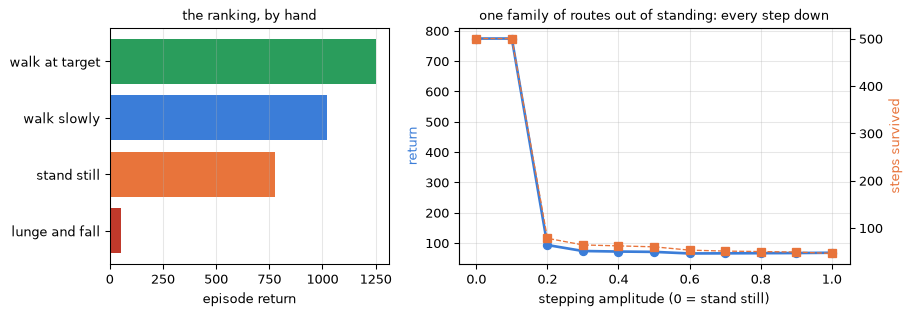

In [2]:
import matplotlib.pyplot as plt
from soc4180.envs import G1WalkEnv

def open_loop_return(amplitude, env=G1WalkEnv()):
    obs, _ = env.reset(seed=0); total, k = 0.0, 0
    while True:
        a = np.zeros(12, dtype=np.float32)
        a[0], a[6] = amplitude * np.sin(4.0 * env.data.time), -amplitude * np.sin(4.0 * env.data.time)
        a[3], a[9] = amplitude * max(0.0, np.sin(4.0 * env.data.time)), amplitude * max(0.0, -np.sin(4.0 * env.data.time))
        obs, r, term, trunc, _ = env.step(a); total += r; k += 1
        if term or trunc:
            return total, k

amps = np.linspace(0.0, 1.0, 11)
scored = [open_loop_return(A) for A in amps]
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(9.6, 3.4), gridspec_kw={"width_ratios": [1, 1.4]})
names = ["walk at target", "walk slowly", "stand still", "lunge and fall"]
vals = [episode_return(0.5, 500), episode_return(0.2, 500), episode_return(0.0, 500), episode_return(1.3, 46)]
ax0.barh(names, vals, color=["#2a9d5c", "#3b7dd8", "#e8743b", "#c0392b"]); ax0.invert_yaxis()
ax0.set_xlabel("episode return"); ax0.set_title("the ranking, by hand", fontsize=10); ax0.grid(axis="x", alpha=0.3)
ax1.plot(amps, [s[0] for s in scored], "o-", color="#3b7dd8", lw=2)
ax1.set_xlabel("stepping amplitude (0 = stand still)"); ax1.set_ylabel("return", color="#3b7dd8")
ax2 = ax1.twinx(); ax2.plot(amps, [s[1] for s in scored], "s--", color="#e8743b", lw=1)
ax2.set_ylabel("steps survived", color="#e8743b")
ax1.set_title("one family of routes out of standing: every step down", fontsize=10); ax1.grid(alpha=0.3)
fig.tight_layout(); plt.show()

Standing is 776. Every open-loop attempt to step scores **less** — first
because effort and smoothness cost a little, then because it falls.
Walking at 1250 is real, but nothing on this path leads up to it.

------------------------------------------------------------------------

## So why does it stand?

Because a reward describes a *destination*, and training has to find a
*route*.

Standing is worth 776 and is reachable from the starting crouch by doing
nothing. Walking is worth 1250 — but every route from standing to
walking passes through lifting a foot, being briefly unbalanced, and
often **falling**, which is worth almost nothing.

> The optimum is not the problem. The valley in front of it is.

This is a **local optimum**, and it is the single most common failure in
locomotion RL. Nothing in a learning curve announces it: the return
rises, flattens at 776, and stays there looking healthy.

------------------------------------------------------------------------

## The ablation that failed

The natural experiment is to remove reward terms and see what breaks. We
ran all six variants for 30k steps each:

| variant           | steps survived | distance | velocity |
|-------------------|----------------|----------|----------|
| full reward       | 500            | 0.010 m  | 0.001    |
| no alive bonus    | 500            | 0.013 m  | 0.001    |
| no upright term   | 500            | 0.012 m  | 0.001    |
| no effort penalty | 500            | 0.006 m  | 0.001    |
| no smoothness     | 500            | 0.005 m  | 0.001    |
| tracking only     | 500            | 0.023 m  | 0.002    |

**Every variant is identical: stand still, survive, go nowhere.**

The terms we were trying to study never got a chance to matter, because
none of them changes whether *standing* is attractive. **A negative
result, reported as one** — and it tells us the missing ingredient is
not among the terms we had.

------------------------------------------------------------------------

## What a real locomotion reward looks like

This is the actual G1 reward from **MuJoCo Playground**, fetched from
source — not a simplification:

| group | terms |
|------------------------------------|------------------------------------|
| tracking | `tracking_lin_vel` **+1.0**, `tracking_ang_vel` **+0.75** |
| posture | `orientation` −2.0, `ang_vel_xy` −0.15, `pose` −0.1 |
| **feet** | **`feet_air_time` +2.0**, `feet_phase` +1.0, `feet_slip` −0.25 |
| joints | `joint_deviation_hip` −0.25, `joint_deviation_knee` −0.1, `dof_pos_limits` −1.0 |
| safety | `termination` **−100.0**, `collision` −0.1, `contact_force` −0.01 |
| **anti-idling** | **`stand_still` −1.0** |
| switched off | `torques`, `action_rate`, `energy`, `dof_acc`, `base_height`, `alive` |

Twenty-four terms. Ours had five. Two differences matter most.

------------------------------------------------------------------------

## Twenty-four terms, drawn

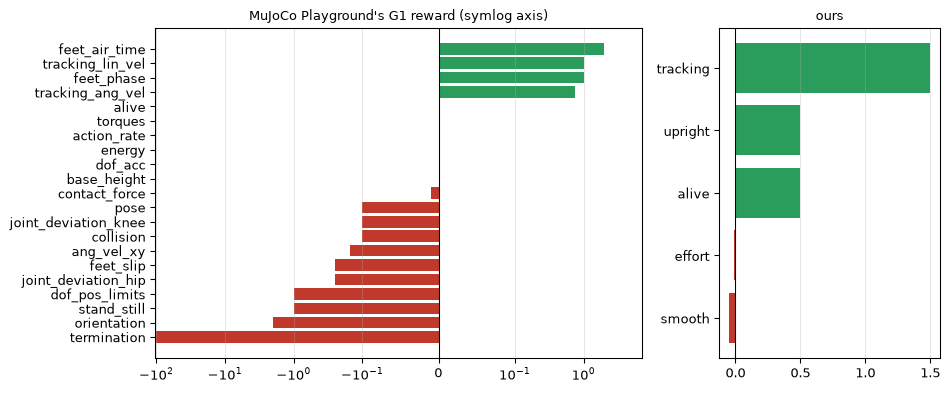

In [3]:
playground = {"tracking_lin_vel": 1.0, "tracking_ang_vel": 0.75, "feet_air_time": 2.0, "feet_phase": 1.0,
              "orientation": -2.0, "ang_vel_xy": -0.15, "pose": -0.1, "feet_slip": -0.25,
              "joint_deviation_hip": -0.25, "joint_deviation_knee": -0.1, "dof_pos_limits": -1.0,
              "collision": -0.1, "contact_force": -0.01, "stand_still": -1.0, "termination": -100.0,
              "alive": 0.0, "torques": 0.0, "action_rate": 0.0, "energy": 0.0, "dof_acc": 0.0,
              "base_height": 0.0}
ours = {"tracking": 1.5, "upright": 0.5, "alive": 0.5, "effort": -0.01, "smooth": -0.05}
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 4.2), gridspec_kw={"width_ratios": [2.2, 1]})
names = sorted(playground, key=lambda k: -playground[k])
vals = np.array([playground[k] for k in names])
ax0.barh(names, vals, color=np.where(vals > 0, "#2a9d5c", "#c0392b")); ax0.invert_yaxis()
ax0.set_xscale("symlog", linthresh=0.1); ax0.axvline(0, color="k", lw=0.8)
ax0.set_title("MuJoCo Playground's G1 reward (symlog axis)", fontsize=10); ax0.grid(axis="x", alpha=0.3)
ax1.barh(list(ours), list(ours.values()), color=["#2a9d5c" if v > 0 else "#c0392b" for v in ours.values()])
ax1.invert_yaxis(); ax1.axvline(0, color="k", lw=0.8); ax1.set_title("ours", fontsize=10); ax1.grid(axis="x", alpha=0.3)
fig.tight_layout(); plt.show()

Two shapes to notice. Theirs has a large one-off **termination** cost
and no alive bonus; ours has the reverse. And theirs pays for a foot in
the air and charges for standing still; ours mentions neither.

------------------------------------------------------------------------

## The two terms we were missing

**`feet_air_time = +2.0`** — the second-largest positive weight in the
whole function. It pays the robot *for having a foot off the ground*.
Not for walking; for the component of walking that standing cannot fake.

**`stand_still = −1.0`** — an explicit penalty for not moving when asked
to. The local optimum is not left to be out-competed; it is **made
unattractive on purpose**.

Also note `alive = 0.0` with `termination = −100.0`. They use the same
idea we did — do not fall — but as a large one-off cost rather than a
per-step bonus. A per-step bonus is exactly what makes *standing*
profitable.

**Our reward described the destination. Theirs also shapes the route.**

------------------------------------------------------------------------

## Test it

Add those two terms to our environment and retrain, changing nothing
else.

In [4]:
from stable_baselines3 import PPO
from soc4180.envs import G1WalkEnv

def train_and_probe(weights, steps=40_000, seed=0):
    env = G1WalkEnv(reward_weights=weights)
    agent = PPO("MlpPolicy", env, verbose=0, seed=seed, device="cpu",
                policy_kwargs=dict(log_std_init=-2.0))   # week 8's fix
    agent.learn(total_timesteps=steps)

    lengths, distances, airborne = [], [], []
    for s in range(3):
        obs, _ = env.reset(seed=s); k, air = 0, 0.0
        while True:
            a, _ = agent.predict(obs, deterministic=True)
            obs, r, terminated, truncated, info = env.step(a)
            k += 1; air += info["air_time"]
            if terminated or truncated:
                break
        lengths.append(k); distances.append(env.data.qpos[0]); airborne.append(air / k)
    return np.mean(lengths), np.mean(distances), np.mean(airborne)

results = []
print(f"{'reward':32} {'steps':>6} {'dist m':>8} {'feet up':>8}")
for name, w in (("ours, unchanged",            {}),
                ("+ stand_still -1.0",         {"stand_still": -1.0}),
                ("+ feet air_time +2.0",       {"air_time": 2.0}),
                ("+ both",                     {"stand_still": -1.0, "air_time": 2.0})):
    t0 = time.time(); L, D, A = train_and_probe(w)
    results.append((name, L, D, A))
    print(f"{name:32} {L:6.0f} {D:8.3f} {A:8.2f}   ({time.time()-t0:.0f}s)")

reward                            steps   dist m  feet up
ours, unchanged                     500    0.018     0.00   (95s)
+ stand_still -1.0                  500    0.015     0.00   (95s)
+ feet air_time +2.0                500    0.016     0.00   (95s)
+ both                              224   -0.524     0.08   (94s)

------------------------------------------------------------------------

## The same table, as a picture

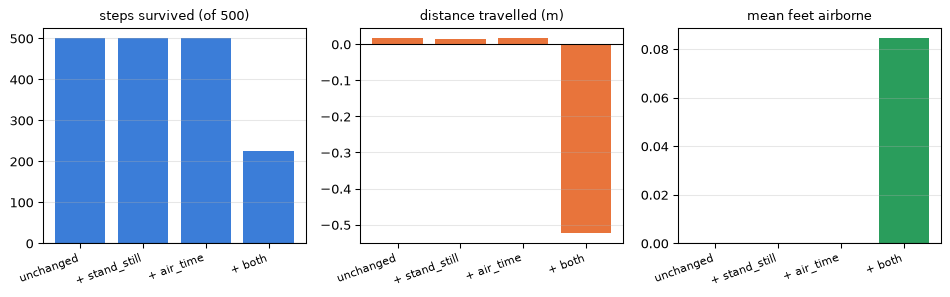

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(10, 3.2))
labels = ["unchanged", "+ stand_still", "+ air_time", "+ both"]
for ax, col, title, k in ((axs[0], "#3b7dd8", "steps survived (of 500)", 1),
                          (axs[1], "#e8743b", "distance travelled (m)", 2),
                          (axs[2], "#2a9d5c", "mean feet airborne", 3)):
    ax.bar(labels, [r[k] for r in results], color=col); ax.set_title(title, fontsize=10)
    ax.set_xticks(range(len(labels)), labels, rotation=20, ha="right", fontsize=8); ax.grid(axis="y", alpha=0.3)
    ax.axhline(0, color="k", lw=0.8)
fig.tight_layout(); plt.show()

------------------------------------------------------------------------

## Read that table carefully

**Either term alone changes nothing.** The robot still stands for all
500 steps with both feet planted. One penalty, or one bounty, is not
enough to make the valley worth crossing.

**Together, they break the optimum.** The robot leaves the standing
pose, lifts its feet — and falls, having travelled *backwards*.

That is progress, and it is not success. We replaced a comfortable local
optimum with a worse one.

> Shaping decides **which** optimum you land in. It does not buy you the
> search needed to find a good one.

*(Single seed, one budget. Treat the direction as real and the exact
numbers as noise — Week 11 requires three seeds for a reason.)*

------------------------------------------------------------------------

## Reward hacking

The failure mode everyone warns about is the opposite of ours: a policy
that scores *brilliantly* while doing something useless.

Classic locomotion examples:

- reward forward velocity of the **torso** → the robot dives forward and
  belly-slides
- reward foot **clearance** → it stands on one leg waving the other
- reward **distance from origin** → it learns to fall over in the right
  direction
- forget `feet_slip` → it skates, feet planted, sliding

Every one is the specification being satisfied exactly. **You cannot
debug this from the reward number** — the number looks great. You have
to watch the video.

> If you have not watched a rollout, you do not know what your policy
> learned.

------------------------------------------------------------------------

## Potential-based shaping

Is there a *safe* way to add guidance? Yes, and it is worth knowing
precisely.

If the extra reward has the form

$$F(s, s') = \gamma\,\Phi(s') - \Phi(s)$$

for any function $\Phi$ of state, then the **optimal policy is
unchanged**. The reason is one line: along any trajectory the extra
terms telescope,

$$\sum_{t=0}^{T-1} \gamma^t\big[\gamma\,\Phi(s_{t+1}) - \Phi(s_t)\big]
= \gamma^{T}\Phi(s_T) - \Phi(s_0),$$

which depends only on where the trajectory starts and ends — not on the
actions that got it there. Such shaping can only speed up learning,
never redirect it.

Our added terms are *not* of this form — `feet_air_time` is a bounty on
a state, not a difference of potentials, so it genuinely changes what is
optimal. That is why it can produce foot-waving.

**Potential-based shaping is safe and weak; arbitrary shaping is
powerful and dangerous.** Real locomotion rewards are firmly in the
second category, which is why they are tuned so carefully.

------------------------------------------------------------------------

## Practical rules

1.  **Rank behaviours by hand first.** If the reward does not prefer
    what you prefer, no amount of training will.
2.  **Then ask about the route,** not just the destination. Is there a
    path of improving return from the initial policy to the one you
    want?
3.  **Make the local optimum unattractive** rather than hoping the good
    one wins.
4.  **One term at a time**, with a fixed seed and budget, and record
    everything.
5.  **Watch the video.** Always.
6.  **Report the negative results.** Our six-way ablation showing
    nothing is a finding: it said the missing ingredient was not among
    the terms we had.

------------------------------------------------------------------------

## Lab class: on your laptop

``` bash
uv run weeks/09-reward/lab_reward.py      # torch + SB3: uv sync --extra rl
```

`VARIANTS` lists reward weightings; a number key selects one, `T` trains
it in the background (95 s), the trained policy then drives the window;
`ENTER` prints every term. **The code is complete**: `extra_reward` is
potential-based shaping with the theorem in its docstring, and a
velocity bonus for contrast.

| Step | Do | Right looks like |
|------------------------|------------------------|------------------------|
| 1 | `1`, `T` | a prediction from the ranking first |
| 2 | watch, `ENTER` | it stands: 778, 500 steps, living on alive and upright |
| 3 | `4` (+ both), `T`; then `2`, `3` | 224 steps, −0.524 m, feet up 0.08; each term alone changes nothing |
| 4 | `EXTRA = "potential"`, `1`, `T` | 778 again: the theorem kept its promise |
| 5 | `EXTRA = "velocity"`, `upright: 0`, `T` | still standing at 40k: a moved optimum is not a found one |

------------------------------------------------------------------------

## Lab class: `shape.py`, scored twice

``` bash
uv run weeks/09-reward/shape.py --variant both
uv run weeks/09-reward/shape.py --variant no_upright --extra velocity --no-viewer
```

Trains PPO on a variant, then scores the policy on the reward it was
trained on *and* on the original — the honest number — and replays it.

| variant    | extra     | on its reward | on the original | steps | distance | feet up |
|-----------|-----------|-----------|-----------|-----------|-----------|-----------|
| unchanged  | none      | 778.1         | 778.1           | 500   | +0.018   | 0.00    |
| both       | none      | 260.4         | 324.7           | 224   | −0.524   | 0.08    |
| unchanged  | potential | 778.4         | 778.5           | 500   | +0.022   | 0.00    |
| no_upright | velocity  | 529.4         | 779.0           | 500   | +0.026   | 0.00    |

| Step | Does | Calls |
|------------------------|------------------------|------------------------|
| 2 | the env, wrapped with the extra term | `gym.Wrapper`, `G1WalkEnv(reward_weights)` |
| 3 | train | `PPO(…, gamma, log_std_init=-2)`, `learn` |
| 4 | evaluate on both rewards | `predict(deterministic=True)` |

------------------------------------------------------------------------

## Exercises

1.  **Tune the pair.** Sweep `stand_still` over −0.5, −1, −2 with
    `air_time` fixed at +2. Is there a setting that walks forward rather
    than backwards?
2.  **Backwards.** Our policy moved backwards. Which term should have
    prevented that, and why did tracking not?
3.  **Termination instead of alive.** Replace the alive bonus with a
    −100 termination penalty, as playground does. Does standing still
    remain optimal?
4.  **Hack it deliberately.** Reward torso $x$-velocity with no
    orientation term and train. Describe what it learns. Watch the video
    before writing.
5.  **Potential-based.** Add \$(s) = \$ (distance travelled) as a
    potential-based term. Verify empirically that the ranking of
    standing versus walking is unchanged.
6.  **Three seeds.** Re-run the “+ both” configuration with seeds 0,
    1, 2. How much of the effect survives?

------------------------------------------------------------------------

## Next week

**10 — scaling.** Every result today was limited by budget: 40k steps,
one seed, minutes of CPU. Real locomotion policies train for **150–200
million** steps across thousands of parallel environments on a GPU.

We have a reward that now points the right way and a search too small to
follow it. Next week we buy the search.